**Phase 1: Data Understanding**

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load Dataset
df = pd.read_csv("upi_transactions_2024.csv")

In [3]:
print("Rows: ",df.shape[0],"\nColumns: ", df.shape[1])

Rows:  250000 
Columns:  17


In [4]:
df.head()

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   transaction id      250000 non-null  object
 1   timestamp           250000 non-null  object
 2   transaction type    250000 non-null  object
 3   merchant_category   250000 non-null  object
 4   amount (INR)        250000 non-null  int64 
 5   transaction_status  250000 non-null  object
 6   sender_age_group    250000 non-null  object
 7   receiver_age_group  250000 non-null  object
 8   sender_state        250000 non-null  object
 9   sender_bank         250000 non-null  object
 10  receiver_bank       250000 non-null  object
 11  device_type         250000 non-null  object
 12  network_type        250000 non-null  object
 13  fraud_flag          250000 non-null  int64 
 14  hour_of_day         250000 non-null  int64 
 15  day_of_week         250000 non-null  object
 16  is

In [6]:
df.describe(include="all")

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
count,250000,250000,250000,250000,250000.000000,250000,250000,250000,250000,250000,250000,250000,250000,250000.000000,250000.000000,250000,250000.000000
unique,250000,248610,4,10,NaN,2,5,5,10,8,8,3,4,NaN,NaN,7,NaN
top,TXN0000249984,2024-07-23 21:31:06,P2P,Grocery,NaN,SUCCESS,26-35,26-35,Maharashtra,SBI,SBI,Android,4G,NaN,NaN,Monday,NaN
freq,1,3,112445,49966,NaN,237624,87432,87864,37427,62693,62378,187777,149813,NaN,NaN,36495,NaN
mean,NaN,NaN,NaN,NaN,1311.756036,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001920,14.681032,NaN,0.285348
std,NaN,NaN,NaN,NaN,1848.059224,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.043776,5.188304,NaN,0.451581
min,NaN,NaN,NaN,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,0.000000
25%,NaN,NaN,NaN,NaN,288.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,11.000000,NaN,0.000000
50%,NaN,NaN,NaN,NaN,629.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,15.000000,NaN,0.000000
75%,NaN,NaN,NaN,NaN,1596.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,19.000000,NaN,1.000000


In [7]:
df.columns

Index(['transaction id', 'timestamp', 'transaction type', 'merchant_category',
       'amount (INR)', 'transaction_status', 'sender_age_group',
       'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank',
       'device_type', 'network_type', 'fraud_flag', 'hour_of_day',
       'day_of_week', 'is_weekend'],
      dtype='object')

**Phase 2: Data Quality Assesment & Cleaning**

In [8]:
# Create a copy of the dataset
df_clean = df.copy()

In [9]:
# Rename columns
df_clean.rename(columns={
    "transaction id": "transaction_id",
    "amount (INR)": "amount_INR", "transaction type": "transaction_type",
    "transaction status": "transaction_status", "fraud flag": "fraud_flag"
}, inplace=True)

In [10]:
# Check missing values
df_clean.isnull().sum()

,0
transaction_id,0
timestamp,0
transaction_type,0
merchant_category,0
amount_INR,0
transaction_status,0
sender_age_group,0
receiver_age_group,0
sender_state,0
sender_bank,0


In [11]:
# Check duplicate rows
df_clean.duplicated().sum()

np.int64(0)

In [12]:
# Check datatypes
df_clean.dtypes

,0
transaction_id,object
timestamp,object
transaction_type,object
merchant_category,object
amount_INR,int64
transaction_status,object
sender_age_group,object
receiver_age_group,object
sender_state,object
sender_bank,object


In [13]:
# Convert timestamp to datetime
df_clean["timestamp"] = pd.to_datetime(
    df_clean["timestamp"]
)
df_clean["timestamp"].dtype

dtype('<M8[ns]')

In [14]:
# Check for invalid transaction amounts
(df_clean["amount_INR"] <= 0).sum()

np.int64(0)

In [15]:
# Verify fraud flag values
df_clean["fraud_flag"].value_counts()

,count
fraud_flag,
0,249520
1,480


In [16]:
# Verify transaction status
df_clean["transaction_status"].value_counts()

,count
transaction_status,
SUCCESS,237624
FAILED,12376


In [17]:
# Save cleaned dataset
df_clean.to_csv(
    "upi_transactions_clean.csv",
    index=False
)

**Phase 3: Feature Engineering**

In [18]:
# Date Features

df_clean["year"] = df_clean["timestamp"].dt.year

df_clean["month"] = df_clean["timestamp"].dt.month

df_clean["month_name"] = df_clean["timestamp"].dt.month_name()

df_clean["day"] = df_clean["timestamp"].dt.day

df_clean["hour"] = df_clean["timestamp"].dt.hour

df_clean["weekday"] = df_clean["timestamp"].dt.day_name()

In [19]:
# Weekend Flag
df_clean["is_weekend"] = (
    df_clean["timestamp"].dt.weekday >= 5
).astype(int)

In [20]:
# Transaction Amount Buckets
df_clean["amount_bucket"] = pd.cut(
    df_clean["amount_INR"],
    bins=[0,500,2000,5000,10000,float("inf")],
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High",
        "Premium"
    ]
)

In [21]:
df_clean["amount_bucket"]

,amount_bucket
0,Medium
1,Medium
2,Low
3,High
4,Medium
...,...
249995,Low
249996,High
249997,Low
249998,Low


In [22]:
# Fraud Amount
df_clean["fraud_amount"] = (
    df_clean["amount_INR"] *
    df_clean["fraud_flag"]
)
df_clean.loc[df_clean["fraud_flag"] == 1, "fraud_amount"]


,fraud_amount
740,361
1228,479
2777,162
3761,754
3962,402
...,...
247717,356
247880,450
248661,152
248716,457


In [23]:
# Time Period Classification
def classify_time(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

df_clean["time_period"] = (
    df_clean["hour"].apply(classify_time)
)


In [24]:
# Save Feature Engineered Dataset
df_clean.to_csv(
    "upi_transactions_featured.csv",
    index=False
)

**Phase 4: Exploratory Data Analysis (EDA)**

Transaction Analysis


In [25]:
# Total Transaction Volume
print("Total Transaction Volume:",df_clean["amount_INR"].sum())
# Average Transaction Amount
print("Average Transaction Amount:",df_clean["amount_INR"].mean())


Total Transaction Volume: 327939009
Average Transaction Amount: 1311.756036


transaction_type
P2P             112445
P2M              87660
Bill Payment     37368
Recharge         12527
Name: count, dtype: int64


<Axes: xlabel='transaction_type'>

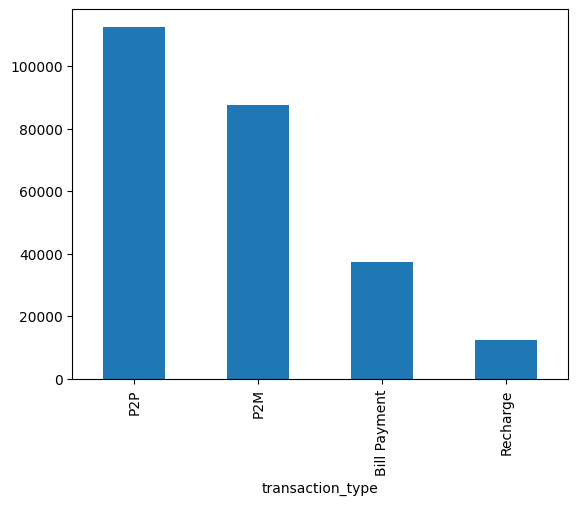

In [26]:
# Transaction Type Distribution

print(df_clean["transaction_type"].value_counts())
df_clean["transaction_type"].value_counts().plot(kind="bar")

In [27]:
# Merchant Category Analysis
df_clean.groupby(
    "merchant_category"
)["amount_INR"].sum()



,amount_INR
merchant_category,
Education,38704346
Entertainment,8309080
Food,19919402
Fuel,38982575
Grocery,58277893
Healthcare,6874159
Other,21073449
Shopping,76863207
Transport,6192416


Customer Analysis

In [28]:
# Age Group Analysis
df_clean["sender_age_group"].value_counts()

df_clean.groupby(
    "sender_age_group"
)["amount_INR"].sum()



,amount_INR
sender_age_group,
18-25,74473936
26-35,115959771
36-45,89533745
46-55,33116261
56+,14855296


<Axes: ylabel='count'>

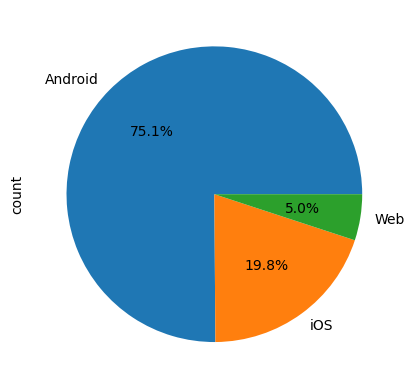

In [29]:
# Device Analysis
df_clean["device_type"].value_counts()

df_clean["device_type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)



In [30]:
# Network Analysis
df_clean["network_type"].value_counts()

,count
network_type,
4G,149813
5G,62582
WiFi,25134
3G,12471


Bank & State Analysis

In [31]:
# State-wise Transaction Volume
state_volume = df_clean.groupby(
    "sender_state"
)["amount_INR"].sum()

state_volume.sort_values(
    ascending=False
)


,amount_INR
sender_state,
Maharashtra,49043948
Uttar Pradesh,40035717
Karnataka,38451158
Tamil Nadu,33343518
Delhi,32689865
Telangana,29750930
Rajasthan,26730470
Gujarat,25988190
Andhra Pradesh,25952619


In [32]:
# State-wise Transaction Count
df_clean["sender_state"].value_counts()


,count
sender_state,
Maharashtra,37427
Uttar Pradesh,30125
Karnataka,29756
Tamil Nadu,25367
Delhi,24870
Telangana,22435
Gujarat,20061
Andhra Pradesh,20006
Rajasthan,19981


In [33]:
# Bank-wise Transaction Count
df_clean["sender_bank"].value_counts()

,count
sender_bank,
SBI,62693
HDFC,37485
ICICI,29769
IndusInd,25173
Axis,25042
PNB,24946
Yes Bank,24860
Kotak,20032


In [34]:
# Bank-wise Transaction Volume
df_clean.groupby(
    "sender_bank"
)["amount_INR"].sum()

,amount_INR
sender_bank,
Axis,32472530
HDFC,49791194
ICICI,38731193
IndusInd,32842711
Kotak,26315412
PNB,32476972
SBI,82816520
Yes Bank,32492477


Time Analysis

In [35]:
# Monthly Trend
df_clean.groupby(
    "month_name"
)["amount_INR"].sum()

,amount_INR
month_name,
April,26988791
August,27845907
December,27311087
February,25826330
January,27456691
July,28079905
June,27032118
March,27508202
May,28024857


In [36]:
# Weekday Trend
df_clean.groupby(
    "weekday"
)["amount_INR"].sum()

,amount_INR
weekday,
Friday,46332583
Monday,47882908
Saturday,45867936
Sunday,47572544
Thursday,46620985
Tuesday,46846390
Wednesday,46815663


<Axes: xlabel='hour'>

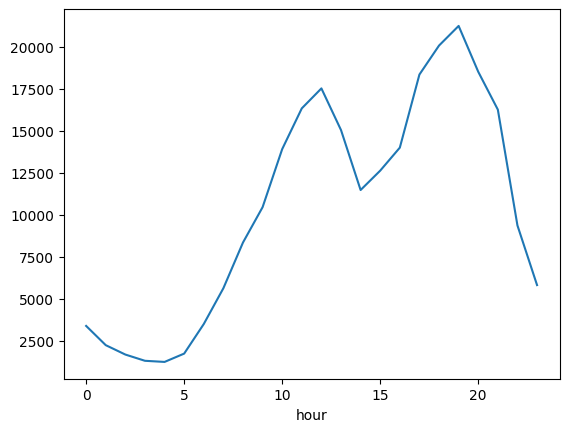

In [37]:
# Hourly Transactions
df_clean.groupby(
    "hour"
).size()
df_clean.groupby(
    "hour"
).size().plot()

In [38]:
# Time Period Analysis
df_clean["time_period"].value_counts()

,count
time_period,
Evening,78142
Afternoon,70642
Morning,59904
Night,41312


Fraud Analysis

In [39]:
df_clean[df_clean["fraud_flag"] == 1].shape


(480, 26)

In [40]:
def fraud_summary(df, column):
    return (
        df.groupby(column)
        .agg(
            Total_Transactions=("fraud_flag", "count"),
            Fraud_Transactions=("fraud_flag", "sum"),
            Fraud_Percentage=("fraud_flag", lambda x: x.mean() * 100)
        )
        .sort_values("Fraud_Percentage", ascending=False)
    )


In [41]:
# Fraud by state
fraud_summary(df_clean, "sender_state")

,Total_Transactions,Fraud_Transactions,Fraud_Percentage
sender_state,,,
Karnataka,29756,69,0.231886
Rajasthan,19981,46,0.230219
Gujarat,20061,43,0.214346
Delhi,24870,50,0.201045
Maharashtra,37427,71,0.189703
West Bengal,19972,35,0.175245
Andhra Pradesh,20006,35,0.174948
Telangana,22435,39,0.173836
Uttar Pradesh,30125,52,0.172614


In [42]:
# Fraud by Bank
fraud_summary(df_clean, "sender_bank")

,Total_Transactions,Fraud_Transactions,Fraud_Percentage
sender_bank,,,
Kotak,20032,50,0.249601
ICICI,29769,66,0.221707
PNB,24946,52,0.208450
IndusInd,25173,52,0.206571
Axis,25042,49,0.195671
SBI,62693,109,0.173863
HDFC,37485,62,0.165399
Yes Bank,24860,40,0.160901


In [43]:
# Fraud by Transaction Type
fraud_summary(df_clean, "transaction_type")

,Total_Transactions,Fraud_Transactions,Fraud_Percentage
transaction_type,,,
Recharge,12527,30,0.239483
Bill Payment,37368,77,0.206059
P2M,87660,167,0.190509
P2P,112445,206,0.183201


In [44]:
# Fraud by Device
fraud_summary(df_clean, "device_type")

,Total_Transactions,Fraud_Transactions,Fraud_Percentage
device_type,,,
Web,12610,26,0.206186
Android,187777,364,0.193847
iOS,49613,90,0.181404


In [45]:
# Fraud by Network
fraud_summary(df_clean, "network_type")

,Total_Transactions,Fraud_Transactions,Fraud_Percentage
network_type,,,
WiFi,25134,59,0.234742
3G,12471,24,0.192446
4G,149813,282,0.188235
5G,62582,115,0.183759


In [46]:
# Fraud by Time Period
fraud_summary(df_clean, "time_period")

,Total_Transactions,Fraud_Transactions,Fraud_Percentage
time_period,,,
Night,41312,89,0.215434
Afternoon,70642,139,0.196767
Evening,78142,148,0.189399
Morning,59904,104,0.173611


**Phase 5: KPI Design**

In [47]:
# Total Transactions
total_transactions = len(df_clean)

# Total Transaction Volume
total_volume = df_clean["amount_INR"].sum()

# Average Transaction Value
average_transaction = df_clean["amount_INR"].mean()

# Maximum Transaction
max_transaction = df_clean["amount_INR"].max()

# Minimum Transaction
min_transaction = df_clean["amount_INR"].min()


# Fraud Transactions
fraud_transactions = df_clean["fraud_flag"].sum()

# Fraud Rate
fraud_rate = (
    fraud_transactions /
    total_transactions
) * 100

# Fraud Amount
fraud_amount = df_clean["fraud_amount"].sum()

# Successful Transactions
successful_transactions = (
    df_clean["transaction_status"] == "SUCCESS"
).sum()

# Success Rate
success_rate = (
    successful_transactions /
    total_transactions
) * 100

# Most Active State
most_active_state = (
    df_clean["sender_state"]
    .value_counts()
    .idxmax()
)

# Most Active Bank
most_active_bank = (
    df_clean["sender_bank"]
    .value_counts()
    .idxmax()
)

# Most Used Device
most_used_device = (
    df_clean["device_type"]
    .value_counts()
    .idxmax()
)

# Most Common Transaction Type
most_common_transaction = (
    df_clean["transaction_type"]
    .value_counts()
    .idxmax()
)

In [48]:
# Print KPI Summary
print(f"Total Transactions      : {total_transactions:,}")
print(f"Total Volume            : ₹{total_volume:,.2f}")
print(f"Average Transaction     : ₹{average_transaction:.2f}")
print(f"Maximum Transaction     : ₹{max_transaction:,.2f}")
print(f"Minimum Transaction     : ₹{min_transaction:,.2f}")
print(f"Fraud Transactions      : {fraud_transactions}")
print(f"Fraud Rate              : {fraud_rate:.2f}%")
print(f"Fraud Amount            : ₹{fraud_amount:,.2f}")
print(f"Success Rate            : {success_rate:.2f}%")
print(f"Most Active State       : {most_active_state}")
print(f"Most Active Bank        : {most_active_bank}")
print(f"Most Used Device        : {most_used_device}")
print(f"Most Common Transaction : {most_common_transaction}")

Total Transactions      : 250,000
Total Volume            : ₹327,939,009.00
Average Transaction     : ₹1311.76
Maximum Transaction     : ₹42,099.00
Minimum Transaction     : ₹10.00
Fraud Transactions      : 480
Fraud Rate              : 0.19%
Fraud Amount            : ₹719,631.00
Success Rate            : 95.05%
Most Active State       : Maharashtra
Most Active Bank        : SBI
Most Used Device        : Android
Most Common Transaction : P2P


# Key Insights

## Executive Summary

- The dataset contains **250,000 UPI transactions** with a total transaction value of **₹327.94 million**, indicating a large and diverse transaction base suitable for business analysis.

- The average transaction amount is **₹1,311.76**, with transaction values ranging from **₹10** to **₹42,099**, reflecting a wide variety of payment sizes.

- Out of all transactions, only **480** were flagged as fraudulent, resulting in a **fraud rate of 0.19%**, indicating that fraudulent transactions are relatively rare.

- The total amount involved in fraudulent transactions is **₹719,631**, highlighting the financial impact of fraud despite its low occurrence.

- The overall transaction success rate is **95.05%**, suggesting a highly reliable UPI payment ecosystem with very few failed or unsuccessful transactions.

- **Maharashtra** recorded the highest number of transactions, making it the **most active state** in the dataset.

- **State Bank of India (SBI)** processed the highest number of transactions, making it the **most active banking institution** in the analysis.

- **Android** was the most commonly used device for UPI transactions, indicating its dominant market share among users.

- **Peer-to-Peer (P2P)** transfers were the **most frequently performed transaction type**, showing that person-to-person payments form the largest portion of UPI activity.

---

These insights provide a high-level overview of transaction volume, user behavior, banking trends, and fraud characteristics. The findings will be further explored using SQL queries and visualized through interactive Power BI dashboards in the subsequent phases of the project.